# Lab 08 v3 — Gameplay Policy SFT

**Goal:** teach Qwen to play Wordle under the exact Lab 04 deployment interface without collapsing onto a tiny on-policy dataset.

We now have two failed extremes:

```text
Lab 07:
broad synthetic curriculum
→ learned Wordle semantics
→ poor gameplay transfer

Lab 08 v2:
exact deployment states
→ only 142 unique states
→ severe overfitting
→ gameplay got worse
```

So this experiment combines the useful parts:

1. start from the **Lab 07 checkpoint**;
2. regenerate the broad symbolic expert trajectories;
3. render every expert state using the **exact Lab 04 gameplay prompt**;
4. add the canonical on-policy correction states from Lab 08 v2 as a small hard-example supplement;
5. train on the combined gameplay-policy dataset;
6. rerun the frozen Lab 04 benchmark.

The hypothesis is:

> broad expert coverage + exact deployment prompt + modest hard-example emphasis should transfer better than either Lab 07 or Lab 08 v2 alone.

## 8.1 Clean start

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from collections import Counter
import hashlib
import json
import math
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from tiny_wordle.game import Turn, score_string
from tiny_wordle.expert import EntropyExpert

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 8.2 Start from Lab 07, not Lab 08 v2

Lab 07 learned useful Wordle semantics. Lab 08 v2 overfit a tiny correction set.

So Lab 07 is the correct starting point.

In [2]:
LAB07_CHECKPOINT = Path("../checkpoints/qwen3-0.6b-wordle-full-sft")

tokenizer = AutoTokenizer.from_pretrained(LAB07_CHECKPOINT)

model = AutoModelForCausalLM.from_pretrained(
    LAB07_CHECKPOINT,
    dtype=torch.float32,
).to(device)

model.eval()

print(type(model).__name__)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForCausalLM
parameters: 596,049,920
device: mps:0


## 8.3 Load the expert

In [3]:
DATA_DIR = Path("../data")

ANSWERS = [
    x.strip().upper()
    for x in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if x.strip()
]

PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")

expert = EntropyExpert(ANSWERS, PATTERNS)

WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print("answers:", len(ANSWERS))
print("pattern matrix:", PATTERNS.shape)

answers: 2315
pattern matrix: (2315, 2315)


## 8.4 Freeze the exact Lab 04 gameplay prompt

This is now the model-facing format for **all** policy supervision.

In [4]:
SYSTEM_RULES = '''Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Example valid response:
CRANE

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched
'''

def format_history_for_model(history: list[Turn]) -> str:
    if not history:
        return "No guesses have been made yet."

    return "\n".join(
        f"{' '.join(t.guess)} -> {' '.join(t.feedback)}"
        for t in history
    )

def build_prompt(history: list[Turn]) -> str:
    return (
        SYSTEM_RULES
        + "\nGame history:\n"
        + format_history_for_model(history)
    )

print(build_prompt([]))

Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Example valid response:
CRANE

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched

Game history:
No guesses have been made yet.


## 8.5 Recreate broad expert gameplay trajectories

These are the same symbolic states used in Lab 06, but now every state is rendered through the exact Lab 04 gameplay prompt.

We exclude action examples from the 11 expert trajectories that fail within six turns.

In [5]:
@dataclass
class ExpertState:
    answer: str
    split: str
    turn: int
    history: list[Turn]
    expert_guess: str
    candidate_count: int

DEV_FIXED = {"PLANT"}

TEST_FIXED = {
    "SHORE", "MIGHT", "BRICK", "GHOST", "KNIFE",
    "DOUBT", "FLING", "ROUND", "CHAMP", "WASTE",
    "BLIND", "POINT", "SLATE", "CRANE", "APPLE",
    "SHEEP", "BANAL", "ALLEY", "AUDIO",
}

def stable_bucket(word: str) -> int:
    digest = hashlib.sha256(word.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

def answer_split(answer: str) -> str:
    if answer in TEST_FIXED:
        return "test"
    if answer in DEV_FIXED:
        return "dev"
    return "dev" if stable_bucket(answer) < 100 else "train"

def play_expert_states(answer: str, max_turns: int = 6):
    candidates = ALL_INDICES.copy()
    history: list[Turn] = []
    states: list[ExpertState] = []
    solved = False

    for turn_number in range(1, max_turns + 1):
        guess_idx = expert.choose(candidates)
        guess = ANSWERS[guess_idx]

        states.append(
            ExpertState(
                answer=answer,
                split=answer_split(answer),
                turn=turn_number,
                history=list(history),
                expert_guess=guess,
                candidate_count=len(candidates),
            )
        )

        feedback = score_string(answer, guess)

        if feedback == "GGGGG":
            solved = True
            break

        history.append(Turn(guess=guess, feedback=feedback))
        candidates = expert.update(candidates, guess_idx, feedback)

        if len(candidates) == 0:
            raise RuntimeError(f"candidate set became empty for {answer}")

    return states, solved

all_states = []
solved_by_answer = {}

for answer in ANSWERS:
    states, solved = play_expert_states(answer)
    all_states.extend(states)
    solved_by_answer[answer] = solved

print("expert states:", len(all_states))
print("solved answers:", sum(solved_by_answer.values()))
print("failed answers:", sum(not x for x in solved_by_answer.values()))

expert states: 8319
solved answers: 2304
failed answers: 11


## 8.6 Convert broad expert states into exact deployment examples

Turn 1 is the same observable state for every answer, so keep one opening example only.

In [6]:
broad_examples = []
opening_kept = False

for state in all_states:
    if state.split == "test":
        continue

    if not solved_by_answer[state.answer]:
        continue

    if state.turn == 1:
        if opening_kept:
            continue
        opening_kept = True

    broad_examples.append({
        "source": "expert",
        "split": state.split,
        "answer": state.answer,
        "turn": state.turn,
        "candidate_count": state.candidate_count,
        "prompt": build_prompt(state.history),
        "response": state.expert_guess,
        "hard_example": False,
    })

print("broad expert examples:", len(broad_examples))

broad expert examples: 5906


## 8.7 Canonical on-policy correction set

We now recreate one on-policy collection pass from the **Lab 07 model**, canonicalize repeated identical observations, and keep only unique observable states.

Unlike Lab 08 v2, these examples will be a supplement—not the whole dataset.

In [7]:
WORD_RE = re.compile(r"^[A-Za-z]{5}$")

def parse_guess(raw_text: str) -> str | None:
    text = raw_text.strip()
    return text.upper() if WORD_RE.fullmatch(text) else None

def render_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def generate_raw_guess(history: list[Turn], max_new_tokens: int = 16) -> str:
    prompt = build_prompt(history)
    text = render_prompt(prompt)
    batch = tokenizer(text, return_tensors="pt").to(device)

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    new = output[0, batch["input_ids"].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True).strip()

MARK_DIGIT = {"B": 0, "Y": 1, "G": 2}

def encode_feedback(feedback: str) -> int:
    value = 0
    for mark in feedback:
        value = value * 3 + MARK_DIGIT[mark]
    return value

def candidate_indices_from_history(history: list[Turn]) -> np.ndarray:
    candidates = ALL_INDICES.copy()

    for turn in history:
        if turn.guess in WORD_TO_INDEX:
            guess_idx = WORD_TO_INDEX[turn.guess]
            pattern_id = encode_feedback(turn.feedback)
            candidates = candidates[
                PATTERNS[guess_idx, candidates] == pattern_id
            ]
        else:
            candidates = np.array(
                [
                    int(idx)
                    for idx in candidates
                    if score_string(
                        ANSWERS[int(idx)],
                        turn.guess,
                    ) == turn.feedback
                ],
                dtype=np.int32,
            )

        if len(candidates) == 0:
            break

    return candidates

def expert_action_for_history(history: list[Turn]) -> tuple[str | None, int]:
    candidates = candidate_indices_from_history(history)

    if len(candidates) == 0:
        return None, 0

    seen = {t.guess for t in history}

    available = np.array(
        [
            int(i)
            for i in candidates
            if ANSWERS[int(i)] not in seen
        ],
        dtype=np.int32,
    )

    if len(available) == 0:
        return None, len(candidates)

    idx = expert.choose(available)
    return ANSWERS[idx], len(candidates)

def canonicalize_history(history: list[Turn]) -> list[Turn]:
    seen = set()
    canonical = []

    for turn in history:
        key = (turn.guess, turn.feedback)

        if key in seen:
            continue

        seen.add(key)
        canonical.append(turn)

    return canonical

## 8.8 Collect a modest on-policy correction set

Use 1,000 train answers plus all dev answers, as in Lab 08 v2.

In [9]:
TRAIN_COLLECTION_LIMIT = 1000

train_answers = [
    w for w in ANSWERS
    if answer_split(w) == "train"
]

dev_answers = [
    w for w in ANSWERS
    if answer_split(w) == "dev"
]

rng = random.Random(SEED)
rng.shuffle(train_answers)

collection_answers = (
    train_answers[:TRAIN_COLLECTION_LIMIT]
    + dev_answers
)

print("collection answers:", len(collection_answers))

collection answers: 1231


In [10]:
onpolicy_raw = []

for i, answer in enumerate(collection_answers, 1):
    history: list[Turn] = []
    seen = set()

    for turn_number in range(1, 7):
        raw = generate_raw_guess(history)
        learner_guess = parse_guess(raw)

        canonical_history = canonicalize_history(history)
        expert_guess, candidate_count = expert_action_for_history(
            canonical_history
        )

        if expert_guess is not None:
            onpolicy_raw.append({
                "source": "on_policy",
                "split": answer_split(answer),
                "answer": answer,
                "turn": turn_number,
                "candidate_count": candidate_count,
                "prompt": build_prompt(canonical_history),
                "response": expert_guess,
                "hard_example": True,
            })

        if learner_guess is None:
            continue

        seen.add(learner_guess)
        feedback = score_string(answer, learner_guess)
        history.append(Turn(learner_guess, feedback))

        if feedback == "GGGGG":
            break

    if i % 200 == 0 or i == len(collection_answers):
        print(f"{i}/{len(collection_answers)} | raw states={len(onpolicy_raw)}")

200/1231 | raw states=1200
400/1231 | raw states=2397
600/1231 | raw states=3597
800/1231 | raw states=4797
1000/1231 | raw states=5997
1200/1231 | raw states=7197
1231/1231 | raw states=7383


## 8.9 Deduplicate on-policy states

One unique observable prompt → one expert action.

In [11]:
prompt_targets = {}

for ex in onpolicy_raw:
    prompt_targets.setdefault(ex["prompt"], set()).add(ex["response"])

ambiguous = {
    p: targets
    for p, targets in prompt_targets.items()
    if len(targets) > 1
}

print("ambiguous on-policy prompts:", len(ambiguous))
assert not ambiguous

onpolicy_dedup = {}

for ex in onpolicy_raw:
    key = (ex["prompt"], ex["response"])
    onpolicy_dedup[key] = ex

onpolicy_examples = list(onpolicy_dedup.values())

print("raw on-policy examples:", len(onpolicy_raw))
print("unique on-policy examples:", len(onpolicy_examples))

ambiguous on-policy prompts: 0
raw on-policy examples: 7383
unique on-policy examples: 142


## 8.10 Combine broad expert data + hard on-policy corrections

We do **not** let the 142-ish on-policy states become the whole training distribution.

Instead, combine:

```text
broad expert gameplay states
+
unique on-policy correction states
```

Then deduplicate exact prompt/target pairs.

If the same state exists in both sources, mark it as a hard example but keep only one copy for now.

In [12]:
combined = {}

for ex in broad_examples + onpolicy_examples:
    key = (ex["prompt"], ex["response"])

    if key not in combined:
        combined[key] = dict(ex)
    else:
        combined[key]["hard_example"] = (
            combined[key]["hard_example"]
            or ex["hard_example"]
        )

combined_examples = list(combined.values())

print("combined unique examples:", len(combined_examples))
print(
    "hard examples:",
    sum(bool(x["hard_example"]) for x in combined_examples),
)

combined unique examples: 2435
hard examples: 142


## 8.11 Split by prompt, not source answer

Once multiple answers can yield the same observable state, the model-facing prompt is the correct split unit.

Use deterministic 90/10 prompt hashing.

The frozen Lab 04 test answers are still never used during data generation.

In [13]:
def prompt_bucket(prompt: str) -> int:
    digest = hashlib.sha256(prompt.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

for ex in combined_examples:
    if "No guesses have been made yet." in ex["prompt"]:
        ex["split"] = "train"
    else:
        ex["split"] = (
            "dev"
            if prompt_bucket(ex["prompt"]) < 100
            else "train"
        )

df = pd.DataFrame(combined_examples)

print(df["split"].value_counts())
print()
print("source counts:")
print(df["source"].value_counts())
print()
print("hard examples:", int(df["hard_example"].sum()))

split
train    2209
dev       226
Name: count, dtype: int64

source counts:
source
expert       2294
on_policy     141
Name: count, dtype: int64

hard examples: 142


## 8.12 Assert prompt isolation and zero ambiguity

In [14]:
prompt_splits = (
    df[["prompt", "split"]]
    .drop_duplicates()
    .groupby("prompt")["split"]
    .nunique()
)

assert prompt_splits.max() == 1

targets_per_prompt = (
    df.groupby("prompt")["response"]
    .nunique()
)

assert targets_per_prompt.max() == 1

print("No prompt crosses splits.")
print("No prompt has conflicting targets.")

No prompt crosses splits.
No prompt has conflicting targets.


## 8.13 Optional hard-example oversampling

The on-policy corrections are valuable, but they should not dominate.

Create a training view where each hard example appears **3 times total**.

That gives them extra weight while preserving broad coverage.

In [15]:
train_df = df.loc[df["split"] == "train"].copy()
dev_df = df.loc[df["split"] == "dev"].copy()

hard_train = train_df.loc[train_df["hard_example"]].copy()

train_augmented = pd.concat(
    [
        train_df,
        hard_train,
        hard_train,
    ],
    ignore_index=True,
)

train_augmented = train_augmented.sample(
    frac=1.0,
    random_state=SEED,
).reset_index(drop=True)

print("base train examples:", len(train_df))
print("hard train examples:", len(hard_train))
print("augmented train examples:", len(train_augmented))
print("dev examples:", len(dev_df))

base train examples: 2209
hard train examples: 129
augmented train examples: 2467
dev examples: 226


## 8.14 Token lengths and training config

Because all prompts now use the Lab 04 interface, measure lengths again.

In [16]:
def render_full_example(prompt: str, response: str) -> tuple[str, str]:
    prompt_text = render_prompt(prompt)
    full_text = prompt_text + response + tokenizer.eos_token
    return prompt_text, full_text

def sequence_length(row) -> int:
    _, full_text = render_full_example(row["prompt"], row["response"])
    return len(tokenizer.encode(full_text, add_special_tokens=False))

max_train_length = max(
    sequence_length(row)
    for _, row in train_augmented.iterrows()
)

max_dev_length = max(
    sequence_length(row)
    for _, row in dev_df.iterrows()
)

MAX_LENGTH = max(
    128,
    max_train_length + 4,
    max_dev_length + 4,
)

print("max train length:", max_train_length)
print("max dev length:", max_dev_length)
print("MAX_LENGTH:", MAX_LENGTH)

max train length: 153
max dev length: 153
MAX_LENGTH: 157


## 8.15 Response-only encoding and dataloaders

In [17]:
def encode_example(row) -> dict:
    prompt_text, full_text = render_full_example(
        row["prompt"],
        row["response"],
    )

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
    )["input_ids"]

    full_ids = tokenizer(
        full_text,
        add_special_tokens=False,
    )["input_ids"]

    if len(full_ids) > MAX_LENGTH:
        raise ValueError(
            f"{len(full_ids)} > MAX_LENGTH {MAX_LENGTH}"
        )

    labels = (
        [-100] * len(prompt_ids)
        + full_ids[len(prompt_ids):]
    )

    return {
        "input_ids": full_ids,
        "labels": labels,
    }

PAD_ID = tokenizer.pad_token_id or tokenizer.eos_token_id

def collate_batch(rows):
    encoded = [encode_example(row) for row in rows]
    max_len = max(len(x["input_ids"]) for x in encoded)

    input_rows = []
    label_rows = []
    attention_rows = []

    for item in encoded:
        ids = item["input_ids"]
        labels = item["labels"]
        pad = max_len - len(ids)

        input_rows.append(ids + [PAD_ID] * pad)
        label_rows.append(labels + [-100] * pad)
        attention_rows.append([1] * len(ids) + [0] * pad)

    return {
        "input_ids": torch.tensor(input_rows, dtype=torch.long),
        "labels": torch.tensor(label_rows, dtype=torch.long),
        "attention_mask": torch.tensor(attention_rows, dtype=torch.long),
    }

BATCH_SIZE = 16
VAL_BATCH_SIZE = 32

train_records = train_augmented.to_dict("records")
dev_records = dev_df.to_dict("records")

train_loader = DataLoader(
    train_records,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(
    dev_records,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

print("train batches:", len(train_loader))
print("dev batches:", len(val_loader))

train batches: 155
dev batches: 8


## 8.16 Baseline gameplay-policy validation loss

In [18]:
@torch.no_grad()
def evaluate_loss(model, loader) -> float:
    model.eval()
    losses = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        losses.append(
            outputs.loss.detach().float().cpu().item()
        )

    model.train()
    return float(np.mean(losses))

baseline_val_loss = evaluate_loss(model, val_loader)

print("baseline gameplay-policy validation loss:", baseline_val_loss)

baseline gameplay-policy validation loss: 2.109317883849144


## 8.17 Full-parameter adaptation

This is broader than Lab 08 v2, so return to a single epoch.

Start conservatively:

```text
1 epoch
1e-5 learning rate
AdamW
5% warmup
gradient clip 1.0
```

In [19]:
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
EPOCHS = 1

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.05))

def lr_multiplier(step: int) -> float:
    if step < warmup_steps:
        return (step + 1) / warmup_steps

    progress = (
        (step - warmup_steps)
        / max(1, total_steps - warmup_steps)
    )

    return 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_multiplier,
)

print("total steps:", total_steps)
print("warmup steps:", warmup_steps)

total steps: 155
warmup steps: 7


## 8.18 One-batch sanity check

In [20]:
batch = next(iter(train_loader))
batch = {k: v.to(device) for k, v in batch.items()}

model.train()
optimizer.zero_grad(set_to_none=True)

outputs = model(**batch)
loss = outputs.loss
loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    1.0,
)

print("sanity loss:", loss.detach().float().cpu().item())
print("gradient norm before clipping:", float(grad_norm))

optimizer.zero_grad(set_to_none=True)

sanity loss: 1.6192628145217896
gradient norm before clipping: 20.046607971191406


## 8.19 Train and save best checkpoint

In [21]:
CHECKPOINT_DIR = Path(
    "../checkpoints/"
    "qwen3-0.6b-wordle-gameplay-policy-sft"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOG_EVERY = 25
EVAL_EVERY = max(50, total_steps // 5)

history = []
best_val_loss = float("inf")
global_step = 0
start = time.perf_counter()

model.train()

for batch in train_loader:
    global_step += 1

    batch = {k: v.to(device) for k, v in batch.items()}

    optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0,
    )

    optimizer.step()
    scheduler.step()

    loss_value = loss.detach().float().cpu().item()
    lr = scheduler.get_last_lr()[0]

    history.append({
        "step": global_step,
        "train_loss": loss_value,
        "lr": lr,
        "grad_norm": float(grad_norm),
        "val_loss": None,
    })

    if global_step == 1 or global_step % LOG_EVERY == 0:
        elapsed = time.perf_counter() - start
        print(
            f"step {global_step:4d}/{total_steps} | "
            f"loss {loss_value:.4f} | "
            f"lr {lr:.2e} | "
            f"grad {float(grad_norm):.3f} | "
            f"{elapsed:.1f}s"
        )

    if (
        global_step % EVAL_EVERY == 0
        or global_step == total_steps
    ):
        val_loss = evaluate_loss(model, val_loader)
        history[-1]["val_loss"] = val_loss

        print(
            f"  validation @ step {global_step}: "
            f"{val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print("  new best validation loss; saving checkpoint")

            model.save_pretrained(
                CHECKPOINT_DIR,
                safe_serialization=True,
            )
            tokenizer.save_pretrained(CHECKPOINT_DIR)

        model.train()

elapsed = time.perf_counter() - start

print("\ntraining complete")
print("elapsed seconds:", elapsed)
print("best validation loss:", best_val_loss)

step    1/155 | loss 2.8714 | lr 2.86e-06 | grad 28.477 | 2.0s
step   25/155 | loss 2.1114 | lr 9.64e-06 | grad 20.099 | 49.6s
step   50/155 | loss 1.8099 | lr 8.06e-06 | grad 25.883 | 98.6s
  validation @ step 50: 1.8730
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step   75/155 | loss 1.8878 | lr 5.64e-06 | grad 19.847 | 151.9s
step  100/155 | loss 2.2916 | lr 3.04e-06 | grad 24.165 | 200.9s
  validation @ step 100: 1.8897
step  125/155 | loss 1.4093 | lr 9.80e-07 | grad 18.736 | 254.1s
step  150/155 | loss 2.1432 | lr 2.81e-08 | grad 19.672 | 303.4s
  validation @ step 150: 1.8577
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  validation @ step 155: 1.8577

training complete
elapsed seconds: 320.88715929200407
best validation loss: 1.8577121943235397


## 8.20 Plot training

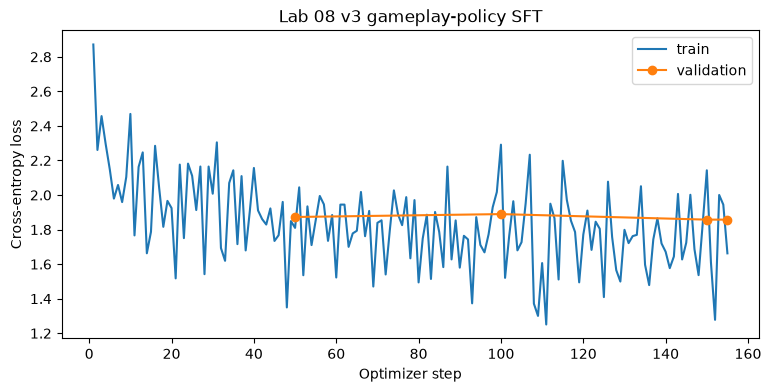

In [22]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 4))
plt.plot(
    history_df["step"],
    history_df["train_loss"],
    label="train",
)

val_points = history_df.dropna(subset=["val_loss"])

plt.plot(
    val_points["step"],
    val_points["val_loss"],
    marker="o",
    label="validation",
)

plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("Lab 08 v3 gameplay-policy SFT")
plt.legend()
plt.show()

## 8.21 Reload the best checkpoint

In [23]:
del model

if device.type == "mps":
    torch.mps.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR,
    dtype=torch.float32,
).to(device)

model.eval()

print("reloaded:", CHECKPOINT_DIR)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

reloaded: ../checkpoints/qwen3-0.6b-wordle-gameplay-policy-sft


# Phase 3 — Frozen gameplay evaluation

In Lab 04, change only:

```python
MODEL_ID = "../checkpoints/qwen3-0.6b-wordle-gameplay-policy-sft"
```

Do not change:

- prompt
- parser
- test answers
- decoding
- thinking mode
- game rules

First run `PLANT`, then the full benchmark.

Compare:

```text
Base Qwen
Lab 07
Lab 08 v2
Lab 08 v3
```

The most important metrics are:

- solve rate
- feedback-dependent solves
- repeat guesses
- history consistency rate
- valid-output rate

If v3 reduces repetition and increases history consistency, then the combined broad + deployment-aligned policy dataset is doing what v2 could not.

# Lab 08 v3 checkpoint

Send me:

1. broad expert example count;
2. raw/unique on-policy correction counts;
3. combined unique example count;
4. hard-example count;
5. train/dev counts after prompt hashing;
6. augmented train count;
7. max sequence lengths;
8. baseline gameplay-policy validation loss;
9. sanity loss + gradient norm;
10. validation checkpoints during training;
11. `PLANT` gameplay trace;
12. full frozen Lab 04 metrics.